In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization

In [2]:
import IPython.display as ipd
import librosa
import librosa.display

In [3]:
metadata=pd.read_csv('UrbanSound8K/UrbanSound8K.csv')

In [4]:
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [5]:
##check whether the dataset is balanced or imbalanced
metadata['class'].value_counts()

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

<h1 style="font-size:40px; color:white; padding:10px;">AUDIO DATA PREPROCESSING </h1>


In [6]:
##read a sample using Librosa
audio_file_path='UrbanSound8K/Audio/fold1/7383-3-0-1.wav'
librosa_audio_data,sample_rate=librosa.load(audio_file_path)

In [7]:
librosa_audio_data.shape

(88200,)

In [8]:
librosa.get_samplerate(audio_file_path)

44100

In [9]:
sample_rate

22050

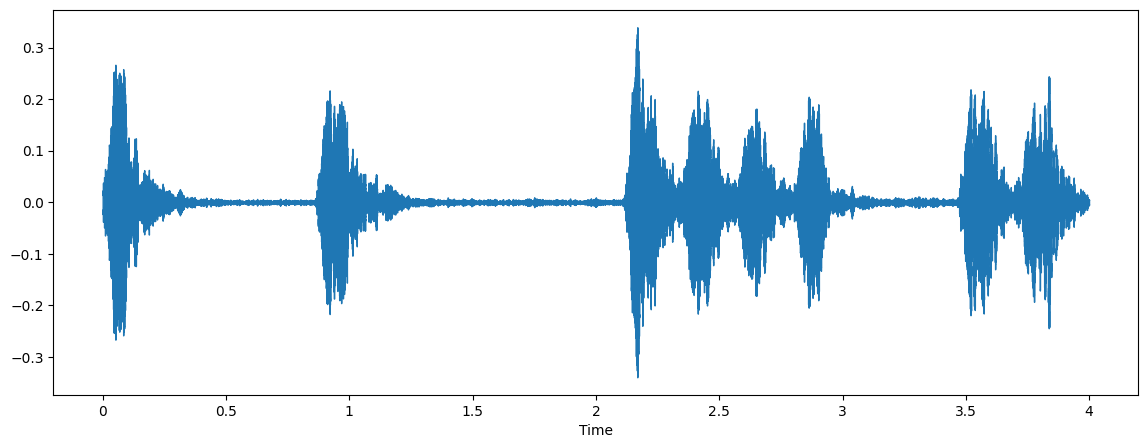

In [10]:
ipd.Audio(audio_file_path)
plt.figure(figsize=(14,5))
librosa.display.waveshow(librosa_audio_data,sr=sample_rate)

In [11]:
##with the help of librosa thaat is convert the sound into mono channel form 

<h1 style="font-size:40px; color:white; padding:10px;">ANN ARCHITECTURE</h1>


EXTRACT FEATURES

In [12]:
mfcc=librosa.feature.mfcc(y=librosa_audio_data,sr=sample_rate,n_mfcc=40)
mfcc.shape

(40, 173)

In [13]:
mfcc

array([[-3.21622498e+02, -2.56845398e+02, -2.46721390e+02, ...,
        -4.01948364e+02, -4.08072723e+02, -4.35104980e+02],
       [ 1.69207581e+02,  1.67166321e+02,  1.52388611e+02, ...,
         1.69238785e+02,  1.58613617e+02,  1.50138458e+02],
       [ 5.15234375e+00, -2.28680496e+01, -3.62438927e+01, ...,
         1.51119175e+01,  9.56732273e+00,  1.37780514e+01],
       ...,
       [ 1.98638725e+00,  4.96574306e+00,  3.51466084e+00, ...,
        -3.56847334e+00, -4.94270754e+00, -3.32263684e+00],
       [-4.99842525e-01, -2.02774668e+00,  2.21275759e+00, ...,
        -8.17015231e-01, -5.76755285e-01, -8.97871554e-01],
       [-1.62972689e+00,  2.92027235e-01,  3.84735703e+00, ...,
        -1.14083409e+00, -4.42689300e-01,  2.83255291e+00]], dtype=float32)

In [14]:
mfcc = np.mean(mfcc.T, axis=0)

In [15]:
mfcc= mfcc.reshape(1, -1)  # (1,108)
mfcc

array([[-4.0101627e+02,  1.5256570e+02,  9.4916439e+00, -1.0767283e+01,
        -1.6241768e+01,  3.2782326e+00, -1.3357742e+01, -8.9584837e+00,
        -4.3042893e+00, -7.7274261e+00, -8.1516570e-01, -3.0388134e+00,
         4.7584338e+00,  8.7069492e+00,  9.3149529e+00,  1.4708637e+01,
         5.3752842e+00,  3.3950895e-02,  6.3612509e-01, -3.4000385e+00,
        -1.4133790e-01, -2.0077803e+00, -4.3623543e+00, -3.3792603e-01,
        -5.5443102e-01,  2.6930330e+00,  2.8375905e+00,  3.5651538e+00,
         4.2402744e+00,  3.7308061e+00,  3.5896857e+00,  6.1247623e-01,
         1.1324850e+00,  1.6056978e+00,  8.2534587e-01, -4.6301123e-01,
        -2.5835404e+00, -1.1586324e+00, -1.5004799e+00,  4.9897924e-01]],
      dtype=float32)

In [16]:
mfcc.shape

(1, 40)

In [17]:
#mfcc = scaler.transform(mfcc)   # same StandardScaler used for training
#mfcc = pca.transform(mfcc)      # if you used PCA


In [18]:
mfcc

array([[-4.0101627e+02,  1.5256570e+02,  9.4916439e+00, -1.0767283e+01,
        -1.6241768e+01,  3.2782326e+00, -1.3357742e+01, -8.9584837e+00,
        -4.3042893e+00, -7.7274261e+00, -8.1516570e-01, -3.0388134e+00,
         4.7584338e+00,  8.7069492e+00,  9.3149529e+00,  1.4708637e+01,
         5.3752842e+00,  3.3950895e-02,  6.3612509e-01, -3.4000385e+00,
        -1.4133790e-01, -2.0077803e+00, -4.3623543e+00, -3.3792603e-01,
        -5.5443102e-01,  2.6930330e+00,  2.8375905e+00,  3.5651538e+00,
         4.2402744e+00,  3.7308061e+00,  3.5896857e+00,  6.1247623e-01,
         1.1324850e+00,  1.6056978e+00,  8.2534587e-01, -4.6301123e-01,
        -2.5835404e+00, -1.1586324e+00, -1.5004799e+00,  4.9897924e-01]],
      dtype=float32)

In [19]:
import os
import scipy

In [20]:
audio_dataset_path='UrbanSound8K/Audio/'

In [21]:
def features_extractor(file_path, sr=22050, n_mfcc=18, n_fft=2048, hop_length=512):
    y, sr = librosa.load(file_path, sr=sr, mono=True)
    if y.size == 0:
        return None

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)

    # Adaptive delta width: odd, <= #frames, and >= 3
    T = mfcc.shape[1]
    w = max(3, min(9, T | 1))   # make odd with |1, cap at 9, floor at 3
    if w > T:                   # if |1 trick overshoots when T==0
        w = T if T % 2 == 1 else max(3, T - 1) ##If clip is extremely short, adjust width again to avoid errors.

    d1 = librosa.feature.delta(mfcc, width=w, mode="nearest") ##for the change of mfcc over time
    d2 = librosa.feature.delta(mfcc, order=2, width=w, mode="nearest")## for the change of d2  itself

    def stats(M):
        return np.hstack([M.mean(axis=1), M.std(axis=1)]) ##this gives mean(18)+std(18)

    feat = np.hstack([stats(mfcc), stats(d1), stats(d2)]).astype(np.float32) ##here total is 108
    return feat

    ##this return an 1D array of seize(108,)


In [22]:
import numpy as np
from tqdm import tqdm
### Now we iterate through every audio file and extract features 
### using Mel-Frequency Cepstral Coefficients
extracted_features=[]
for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_dataset_path),'fold'+str(row["fold"])+'/',str(row["slice_file_name"]))
    final_class_labels=row["class"]
    data=features_extractor(file_name)
    extracted_features.append([data,final_class_labels])

3549it [00:20, 168.13it/s]/opt/anaconda3/envs/tf-cpu/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8317it [00:47, 201.50it/s]/opt/anaconda3/envs/tf-cpu/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/opt/anaconda3/envs/tf-cpu/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [00:50, 173.72it/s]


In [23]:
## converting extracted_features to Pandas dataframe
df=pd.DataFrame(extracted_features,columns=['feature','class'])
df.head()

,feature,class
0,"[-211.93698, 62.581207, -122.813156, -60.74528...",dog_bark
1,"[-417.0052, 99.336624, -42.995586, 51.073326, ...",children_playing
2,"[-452.39316, 112.36253, -37.57807, 43.19586, 8...",children_playing
3,"[-406.47922, 91.1966, -25.043556, 42.78452, 11...",children_playing
4,"[-439.63867, 103.86224, -42.658787, 50.690277,...",children_playing


In [24]:
#Standardize the features
#Create an object of StandardScaler which is present in sklearn.preprocessing
#from sklearn.preprocessing import StandardScaler
#scalar = StandardScaler() 
#scaled_data = pd.DataFrame(scalar.fit_transform(database)) #scaling the data
#scaled_data

In [25]:
x=np.array(df['feature'].tolist())

In [26]:
y=np.array(df['class'].tolist())

In [27]:
x

array([[-2.11936981e+02,  6.25812073e+01, -1.22813156e+02, ...,
         5.27823329e-01,  5.93513846e-01,  8.98519993e-01],
       [-4.17005188e+02,  9.93366241e+01, -4.29955864e+01, ...,
         7.24029601e-01,  6.31867290e-01,  6.50211513e-01],
       [-4.52393158e+02,  1.12362534e+02, -3.75780716e+01, ...,
         5.95030963e-01,  6.14369988e-01,  5.69449782e-01],
       ...,
       [-2.97315338e+02,  1.02090263e+02, -3.67510796e+01, ...,
         4.74849254e-01,  4.70657259e-01,  5.23624480e-01],
       [-3.36923859e+02,  1.15313904e+02, -4.48470955e+01, ...,
         5.93702674e-01,  6.06132567e-01,  5.49192131e-01],
       [-3.07417603e+02,  8.33067245e+01, -2.57565117e+01, ...,
         4.34886694e-01,  4.51838225e-01,  6.21840000e-01]], dtype=float32)

In [28]:
y

array(['dog_bark', 'children_playing', 'children_playing', ...,
       'car_horn', 'car_horn', 'car_horn'], dtype='<U16')

In [29]:
import numpy as np

# feat must be shape (108,) for each file
X = np.vstack([f for (f, lbl) in extracted_features]).astype('float32')  # -> (N, 108) ##extract only feature vector
y_labels = np.array([lbl for (f, lbl) in extracted_features]) ##extract only label
print("X:", X.shape, "y_labels:", y_labels.shape)



X: (8732, 108) y_labels: (8732,)


In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1) Encode labels → one-hot (10 classes)
le = LabelEncoder()
y_int = le.fit_transform(y_labels)                 # (2120,)
num_classes = len(le.classes_)                     # should be 10
y = to_categorical(y_int, num_classes=num_classes) # (2120, 10)

# 2) Stratified split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y_int, random_state=42
)

# 3) Scale (fit on TRAIN only)
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train_raw)
x_test  = scaler.transform(X_test_raw)

# 4) ANN for 108-dim input
model = Sequential([
    Dense(256, activation='relu', input_shape=(108,)),
    BatchNormalization(), Dropout(0.30),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.25),
    Dense(64, activation='relu'),
    Dropout(0.20),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5) Callbacks
es  = EarlyStopping(monitor='val_loss', patience=20, mode='min',
                    restore_best_weights=True, verbose=1)
##learning rate scheduler
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6,
                        min_lr=1e-6, mode='min', verbose=1)
mc  = ModelCheckpoint('saved_models/audio_classification.keras',
                      monitor='val_loss', mode='min',
                      save_best_only=True, verbose=1)

# 6) Train
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=300, batch_size=64, shuffle=True,
    callbacks=[es, rlr, mc], verbose=1
)


Epoch 1/300


/opt/anaconda3/envs/tf-cpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/96 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - accuracy: 0.2398 - loss: 2.3910 
Epoch 1: val_loss improved from None to 1.27228, saving model to saved_models/audio_classification.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4300 - loss: 1.6853 - val_accuracy: 0.6206 - val_loss: 1.2723 - learning_rate: 0.0010
Epoch 2/300
63/96 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.6152 - loss: 1.1268
Epoch 2: val_loss improved from 1.27228 to 0.91112, saving model to saved_models/audio_classification.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6289 - loss: 1.0672 - val_accuracy: 0.6962 - val_loss: 0.9111 - learning_rate: 0.0010
Epoch 3/300
63/96 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.6840 - loss: 0.9382
Epoch 3: val_loss improved from 0.91112 to 0.77499, saving model to saved_models/audio_classification.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6882 - loss: 0.9154 - val_accuracy: 0.7450 - val_loss: 0.7750 - learning_rate: 0.0010
Epoch 4/300


In [31]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


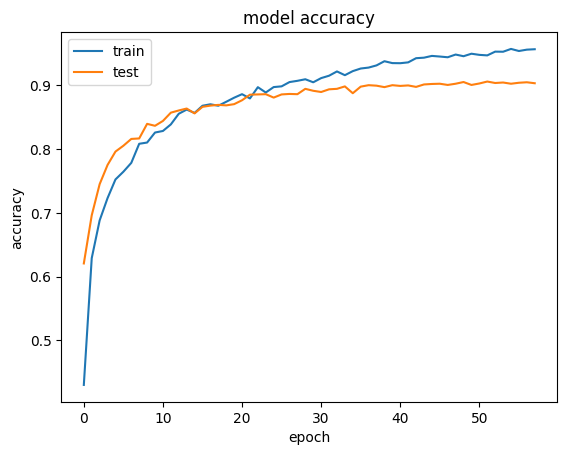

In [32]:

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

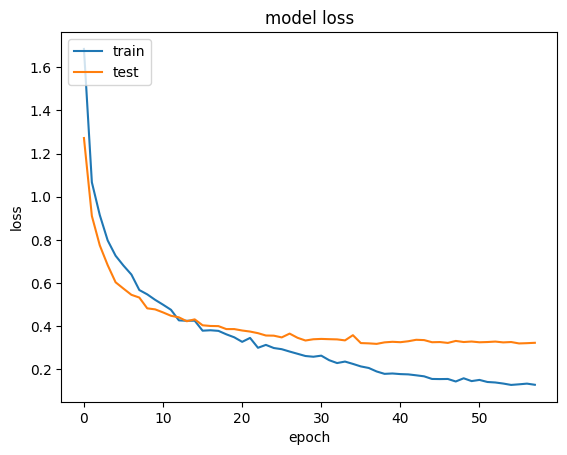

In [33]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [34]:
# Part 3 - Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5)
y_pred

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step


array([[False, False,  True, ..., False, False, False],
       [False, False, False, ..., False, False,  True],
       [False, False, False, ...,  True, False, False],
       ...,
       [False, False, False, ...,  True, False, False],
       [False, False,  True, ..., False, False, False],
       [False, False, False, ..., False,  True, False]])

In [35]:
print('y_test shape/type:', np.array(y_test).shape)
print('y_pred shape/type:', np.array(y_pred).shape)


y_test shape/type: (2620, 10)
y_pred shape/type: (2620, 10)


In [36]:
##because priviously data is in 2D shape
##confusion matrix works on only 1D data
y_true = np.argmax(y_test, axis=1)     # (2620,10) -> (2620,)
y_pred = np.argmax(y_pred, axis=1)     # (2620,10) -> (2620,)

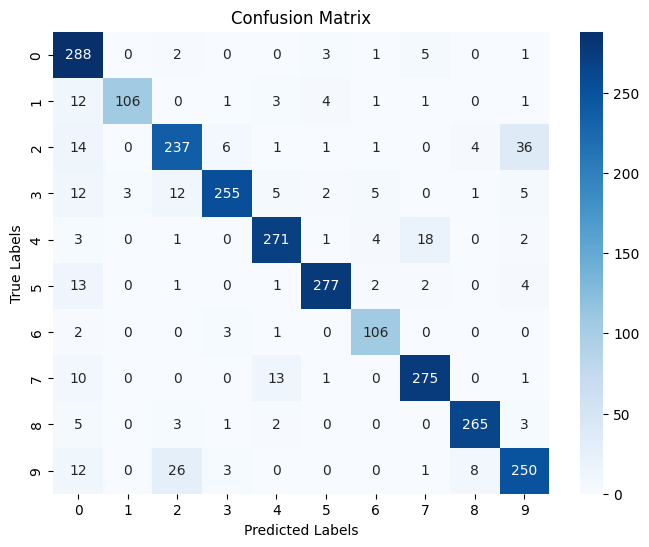

In [37]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# y_true and y_pred must already be defined
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [38]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_true)

In [39]:
score

0.8893129770992366

<h1 style="font-size:40px; color:white; padding:10px;">TESTING DATA</h1>


In [40]:
import librosa
import numpy as np

# -------- 1) Feature extraction (same 108 features as training) --------
def features_extractor(file_path, sr=22050, n_mfcc=18, n_fft=2048, hop_length=512):
    y, sr = librosa.load(file_path, sr=sr, mono=True)
    if y.size == 0:
        return None

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)

    # Adaptive delta width: odd, <= #frames, and >= 3
    T = mfcc.shape[1]
    w = max(3, min(9, T | 1))   # make odd with |1, cap at 9, floor at 3
    if w > T:                   # if |1 trick overshoots when T==0
        w = T if T % 2 == 1 else max(3, T - 1) ##If clip is extremely short, adjust width again to avoid errors.

    d1 = librosa.feature.delta(mfcc, width=w, mode="nearest") ##for the change of mfcc over time
    d2 = librosa.feature.delta(mfcc, order=2, width=w, mode="nearest")## for the change of d2  itself

    def stats(M):
        return np.hstack([M.mean(axis=1), M.std(axis=1)]) ##this gives mean(18)+std(18)

    feat = np.hstack([stats(mfcc), stats(d1), stats(d2)]).astype(np.float32) ##here total is 108
    return feat

    ##this return an 1D array of seize(108,)


# -------- 2) Load + extract 108-dim features --------
file = "UrbanSound8K/Audio/fold1/24074-1-0-3.wav"     # change path

features = features_extractor(file)
features = features.reshape(1, -1)     # (1,108)

# -------- 3) Scale using SAME scaler used in training --------
scaled_features = scaler.transform(features)

# -------- 4) Predict using trained model --------
pred_prob = model.predict(scaled_features)
pred_label = np.argmax(pred_prob, axis=1)

# -------- 5) Decode class name using SAME label encoder --------
prediction = le.inverse_transform(pred_label)
print("Predicted Class:", prediction[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted Class: car_horn


<h1 style="font-size:40px; color:white; padding:10px;">CNN ARCHITECTURE</h1>


In [41]:
SR = 22050              # sampling rate used in your ANN preprocessing
DURATION = 4.0          # seconds used in ANN (pad/truncate to this)
SAMPLES = int(SR * DURATION)
N_MELS = 128            # mel bins (choose what you want; 128 is common)
HOP_LENGTH = 512        # hop length (time resolution)
FMIN = 20
FMAX = SR // 2
CLIP_DB = (-80.0, 0.0)

In [42]:
def load_fixed_length(audio_dataset_path, sr=SR, samples=SAMPLES):
    """Load audio, resample to sr, mono, pad/truncate to `samples` length."""
    y, _ = librosa.load(audio_dataset_path, sr=sr, mono=True)
    if len(y) < samples:
        y = np.pad(y, (0, samples - len(y)), mode='constant')
    elif len(y) > samples:
        # center crop to be consistent (you may use random crop for augmentation instead)
        start = (len(y) - samples) // 2
        y = y[start:start + samples]
    return y

In [43]:
def wav_to_logmel(y, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX):
    """Return mel spectrogram in dB (float32) with shape (n_mels, n_frames)."""
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                         hop_length=hop_length, fmin=fmin, fmax=fmax, power=2.0)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.astype(np.float32)

In [44]:
def normalize_db_to_0_1(mel_db, clip_db=CLIP_DB):
    """Clip dB and scale to [0,1]."""
    lo, hi = clip_db
    mel_clipped = np.clip(mel_db, lo, hi)
    mel_norm = (mel_clipped - lo) / (hi - lo + 1e-9)
    return mel_norm.astype(np.float32)

In [45]:
import os
import numpy as np
import pandas as pd
import os

X_list = []
y_list = []
paths = []

print("Processing all audio files...")

for i, row in metadata.iterrows():
    fold = row['fold']
    fname = row['slice_file_name']
    label = row['class']         # or row['classID'] if you prefer numeric labels
    
    file_path = os.path.join(audio_dataset_path, f"fold{fold}", fname)
    
    if not os.path.exists(file_path):
        continue
    
    # --- Use your functions ---
    y_audio = load_fixed_length(file_path, sr=SR, samples=SAMPLES)
    mel_db = wav_to_logmel(y_audio, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH)
    mel_norm = normalize_db_to_0_1(mel_db)
    
    X_list.append(mel_norm)
    y_list.append(label)
    paths.append(file_path)

# Convert to numpy
X = np.array(X_list)
y = np.array(y_list)

print("X shape before adding channel:", X.shape)

Processing all audio files...
X shape before adding channel: (8732, 128, 173)


In [46]:
X = X[..., np.newaxis]
print("X shape for CNN:", X.shape)


X shape for CNN: (8732, 128, 173, 1)


In [47]:
##lebele encoding

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(y)
y_cat = to_categorical(y_int)

print("Encoded labels:", y_int[:10])


Encoded labels: [3 2 2 2 2 2 2 2 2 1]


In [48]:
from sklearn.model_selection import train_test_split

x_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_int
)

print(x_train.shape, X_test.shape)


(6985, 128, 173, 1) (1747, 128, 173, 1)


<h1 style="font-size:40px; color:white; padding:10px;">CNN MODEL BUILD</h1>


In [49]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = x_train.shape[1:]

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(le.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/opt/anaconda3/envs/tf-cpu/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 173, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 173, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 86, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 86, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43008)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     5,505,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,600,010 (21.36 MB)

 Trainable params: 5,599,562 (21.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [50]:
## MODEL FITTING

history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)


Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 44s 248ms/step - accuracy: 0.2273 - loss: 3.2556 - val_accuracy: 0.1539 - val_loss: 29.9936
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 45s 258ms/step - accuracy: 0.2445 - loss: 2.0621 - val_accuracy: 0.1210 - val_loss: 17.1433
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 266ms/step - accuracy: 0.2688 - loss: 1.9517 - val_accuracy: 0.2513 - val_loss: 2.2234
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 50s 287ms/step - accuracy: 0.2853 - loss: 1.9334 - val_accuracy: 0.3422 - val_loss: 2.0827
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 309ms/step - accuracy: 0.3246 - loss: 1.8614 - val_accuracy: 0.1947 - val_loss: 5.9191
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 309ms/step - accuracy: 0.3688 - loss: 1.7093 - val_accuracy: 0.3815 - val_loss: 1.8254
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 55s 317ms/step - accuracy: 0.3781 - loss: 1.6806 - val_accuracy: 0.2498 - val_loss: 2.4874
Epoch 8/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 55s 315ms/step - accuracy: 0.3951 - loss:

In [51]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


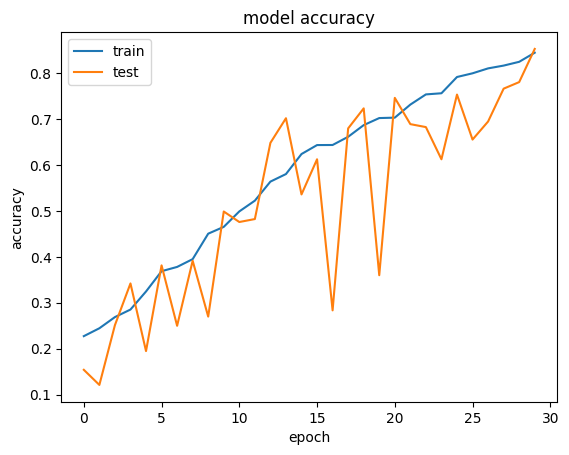

In [52]:

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

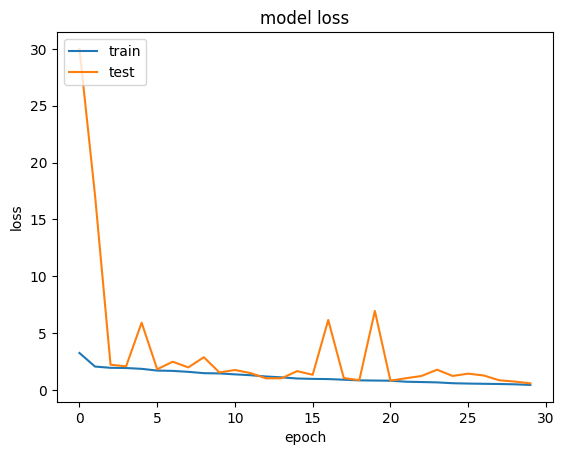

In [53]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [54]:
# Part 3 - Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
y_pred

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step


array([[False, False, False, ..., False, False,  True],
       [ True, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [55]:
print('y_test shape/type:', np.array(y_test).shape)
print('y_pred shape/type:', np.array(y_pred).shape)


y_test shape/type: (1747, 10)
y_pred shape/type: (1747, 10)


In [56]:
##because priviously data is in 2D shape
##confusion matrix works on only 1D data
y_true = np.argmax(y_test, axis=1)     # (2620,10) -> (2620,)
y_pred = np.argmax(y_pred, axis=1)     # (2620,10) -> (2620,)

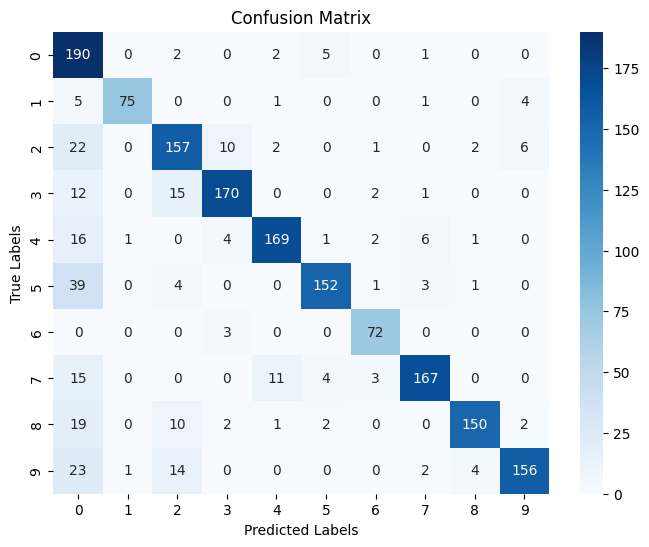

In [63]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# y_true and y_pred must already be defined
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [64]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_true)

In [65]:
score

0.8345735546651403